In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("scaling_results.csv")
df.columns = df.columns.str.strip()  


Slope (alpha_N): 0.0223
Intercept: 0.5469


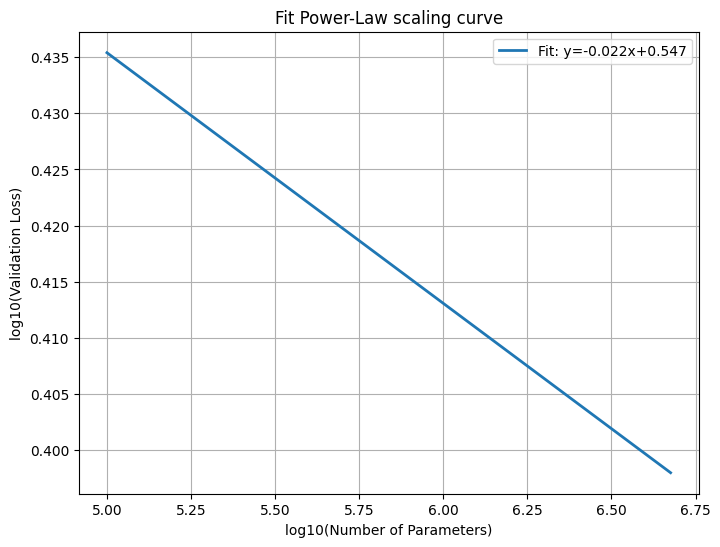

In [2]:
param_df = df[df["Experiment"] == "Parameter Scaling"]
N = param_df["Parameters"].values
L_N = param_df["Validation Loss"].values

log_N = np.log10(N)
log_L_N = np.log10(L_N)

slope, intercept = np.polyfit(log_N,log_L_N, 1)
alpha_N = -slope
print(f"Slope (alpha_N): {alpha_N:.4f}")
print(f"Intercept: {intercept:.4f}")

x_fit = np.linspace(log_N.min(), log_N.max(), 100)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(8,6))

plt.plot(x_fit, y_fit, linewidth=2,label=f"Fit: y={slope:.3f}x+{intercept:.3f}")

plt.xlabel("log10(Number of Parameters)")
plt.ylabel("log10(Validation Loss)")
plt.title("Fit Power-Law scaling curve")
plt.grid(True)
plt.legend()

plt.savefig("scaling_curve.png", dpi=300)
plt.show()

alpha_D = 0.010808001263673626
intercept = 0.4788433442114173


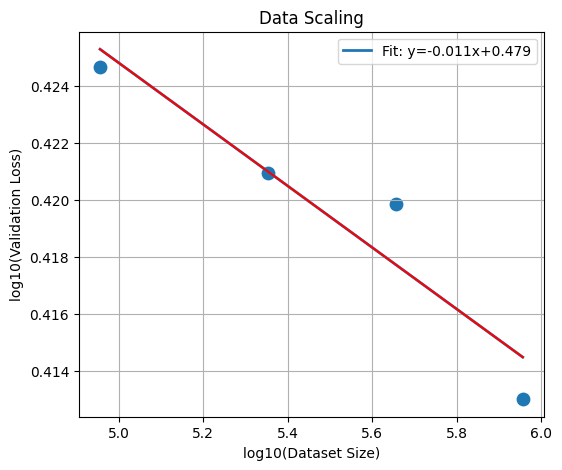

In [3]:
data_df = df[df["Experiment"] == "Data Scaling"]
D = data_df["Dataset_size"].values
L_D = data_df["Validation Loss1"].values

log_D = np.log10(D)
log_L_D = np.log10(L_D)

slope, intercept = np.polyfit(log_D, log_L_D, 1)

alpha_D = -slope

print("alpha_D =", alpha_D)
print("intercept =", intercept)
x = np.linspace(log_D.min(), log_D.max(), 100)
y = slope*x + intercept

plt.figure(figsize=(6,5))
plt.scatter(log_D, log_L_D, s=80)
plt.plot(x, y, linewidth=2,label=f"Fit: y={slope:.3f}x+{intercept:.3f}")
plt.plot(x, y, 'r')

plt.xlabel("log10(Dataset Size)")
plt.ylabel("log10(Validation Loss)")
plt.title("Data Scaling")
plt.grid(True)
plt.legend()

plt.show()

In [4]:
print(f"scaling ratio: {alpha_N/alpha_D:.4f}")

scaling ratio: 2.0640
